In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import xarray as xr
from context_flux_no.nn.utils import num_parameters
from context_flux_no.simulations.pde import Burgers1D
from context_flux_no.waveforms.fourier import TruncatedFourier1D
from context_flux_no.waveforms.grf import (
    GaussianCov,
    GaussianRandomField1D,
)
from tqdm import tqdm


jax.config.update("jax_enable_x64", True)

INFO:2025-10-03 22:01:11,230:jax._src.xla_bridge:749: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


2025-10-03 22:01:11,230 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


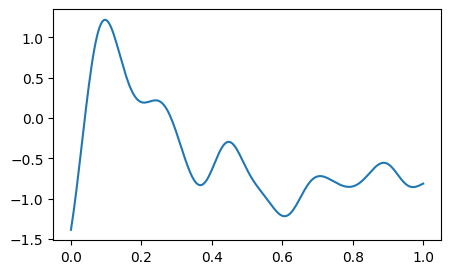

In [2]:
x = jnp.linspace(0, 1, 256)
u0 = GaussianRandomField1D(GaussianCov(0.1)).sample(x, jax.random.key(1))

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0)

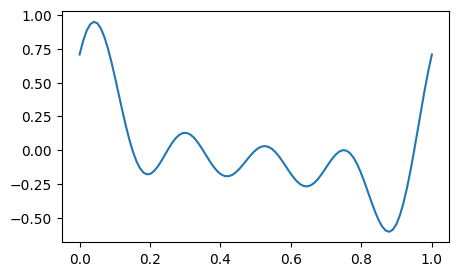

In [3]:
u0 = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)
x = jnp.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0(x))

In [3]:
grf = GaussianRandomField1D(GaussianCov(0.1))
u0_func = lambda x_: grf.sample(x_, key=jax.random.key(0))
burgers = Burgers1D()
# u0_func = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)

sol = burgers.solve_pyclaw(u0_func, (0.0, 1.0), 256, (0.0, 0.2), 500, "periodic")

2025-10-03 22:01:15,393 INFO CLAW: Solution 0 computed for time t=0.000000
2025-10-03 22:01:15,394 INFO CLAW: Solution 1 computed for time t=0.000400
2025-10-03 22:01:15,395 INFO CLAW: Solution 2 computed for time t=0.000800
2025-10-03 22:01:15,396 INFO CLAW: Solution 3 computed for time t=0.001200
2025-10-03 22:01:15,397 INFO CLAW: Solution 4 computed for time t=0.001600
2025-10-03 22:01:15,398 INFO CLAW: Solution 5 computed for time t=0.002000
2025-10-03 22:01:15,399 INFO CLAW: Solution 6 computed for time t=0.002400
2025-10-03 22:01:15,400 INFO CLAW: Solution 7 computed for time t=0.002800
2025-10-03 22:01:15,401 INFO CLAW: Solution 8 computed for time t=0.003200
2025-10-03 22:01:15,402 INFO CLAW: Solution 9 computed for time t=0.003600
2025-10-03 22:01:15,403 INFO CLAW: Solution 10 computed for time t=0.004000
2025-10-03 22:01:15,404 INFO CLAW: Solution 11 computed for time t=0.004400
2025-10-03 22:01:15,405 INFO CLAW: Solution 12 computed for time t=0.004800
2025-10-03 22:01:15,40

2025-10-03 22:01:15,472 INFO CLAW: Solution 83 computed for time t=0.033200
2025-10-03 22:01:15,473 INFO CLAW: Solution 84 computed for time t=0.033600
2025-10-03 22:01:15,474 INFO CLAW: Solution 85 computed for time t=0.034000
2025-10-03 22:01:15,475 INFO CLAW: Solution 86 computed for time t=0.034400
2025-10-03 22:01:15,476 INFO CLAW: Solution 87 computed for time t=0.034800
2025-10-03 22:01:15,477 INFO CLAW: Solution 88 computed for time t=0.035200
2025-10-03 22:01:15,478 INFO CLAW: Solution 89 computed for time t=0.035600
2025-10-03 22:01:15,478 INFO CLAW: Solution 90 computed for time t=0.036000
2025-10-03 22:01:15,479 INFO CLAW: Solution 91 computed for time t=0.036400
2025-10-03 22:01:15,480 INFO CLAW: Solution 92 computed for time t=0.036800
2025-10-03 22:01:15,481 INFO CLAW: Solution 93 computed for time t=0.037200
2025-10-03 22:01:15,482 INFO CLAW: Solution 94 computed for time t=0.037600
2025-10-03 22:01:15,483 INFO CLAW: Solution 95 computed for time t=0.038000
2025-10-03 2

In [4]:
sol

<xarray.DataArray (sample: 1, t: 501, dim: 1, x: 256)> Size: 1MB
array([[[[0.91670261, 0.98163746, 1.0448878 , ..., 1.07401309,
          1.20510731, 1.33587667]],

        [[0.96504682, 0.97234658, 1.03823992, ..., 1.05981771,
          1.18912904, 1.32627273]],

        [[1.00742424, 0.97101561, 1.02896058, ..., 1.04600546,
          1.17332889, 1.31607794]],

        ...,

        [[0.20640063, 0.22251346, 0.23867577, ..., 0.15839069,
          0.17433588, 0.19034034]],

        [[0.20606116, 0.22214634, 0.23828082, ..., 0.15813297,
          0.17405113, 0.19002834]],

        [[0.20572284, 0.22178046, 0.2378872 , ..., 0.15787611,
          0.17376733, 0.18971738]]]], shape=(1, 501, 1, 256))
Coordinates:
  * t        (t) float64 4kB 0.0 0.0004 0.0008 0.0012 ... 0.1992 0.1996 0.2
  * x        (x) float64 2kB 0.001953 0.005859 0.009766 ... 0.9902 0.9941 0.998
  * dim      (dim) <U1 4B 'u'
    nu       (sample) float64 8B 0.0
Dimensions without coordinates: sample

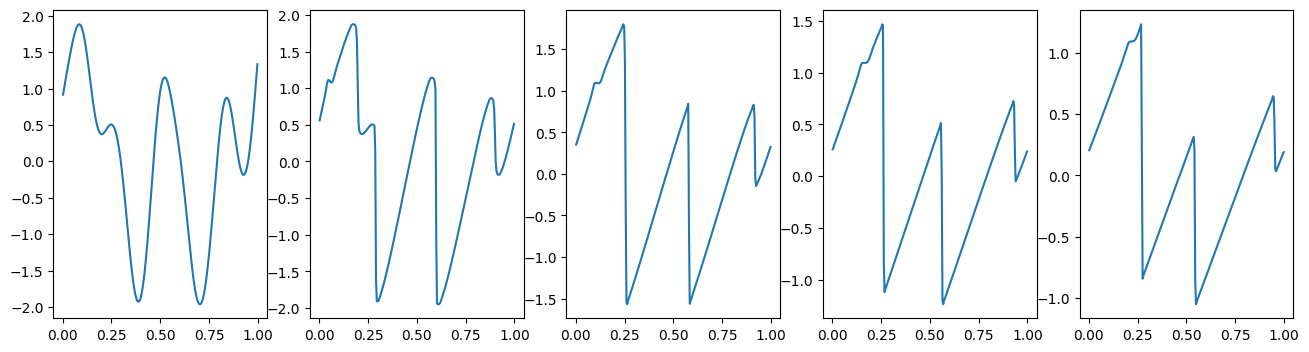

In [4]:
t_vals = (0, 124, 249, 374, 499)
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharex=True)
for j, t_i in enumerate(t_vals):
    axes[j].plot(sol["x"], sol.isel(sample=0, t=t_i, dim=0))

In [5]:
NUM_SAMPLES = 50
SEED = 0


burgers = Burgers1D()
grf = GaussianRandomField1D(GaussianCov(0.1))

keys = jax.random.split(jax.random.key(SEED), NUM_SAMPLES)
solutions = []
for key in tqdm(keys):
    u0_func = lambda x_: grf.sample(x_, key=key)
    sol = burgers.solve_pyclaw(
        u0_func, (0.0, 1.0), 256, (0.0, 0.2), 500, "periodic", verbose=False
    )
    solutions.append(sol)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:08<00:00,  6.24it/s]


In [6]:
dataset = xr.concat(solutions, "sample")

In [ ]:
from pathlib import Path


savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset.to_netcdf(savedir / "burgers_train.hdf5")

In [12]:
from context_flux_no.models.fluxfno import FluxFNO1D


model = FluxFNO1D(
    data_dim=1,
    lift_dim=64,
    depth=4,
    frequency_modes=8,
    stencil_size=2,
    key=jax.random.key(0),
)

u = jnp.asarray(data_array[0, 0])
u.shape

(1, 1024)

In [13]:
u_out = model(u, 6.0 / 1000, 1.0 / 1024)

2025-09-10 18:29:37.782885: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), window={size=1}, dim_labels=bf0_oi0->bf0, custom_call_target="__cudnn$convForward", metadata={op_name="jit(conv_general_dilated)/jit(main)/conv_general_dilated" source_file="/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/equinox/nn/_conv.py" source_line=238}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-09-10 18:29:38.949871: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.167130155s
Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), 

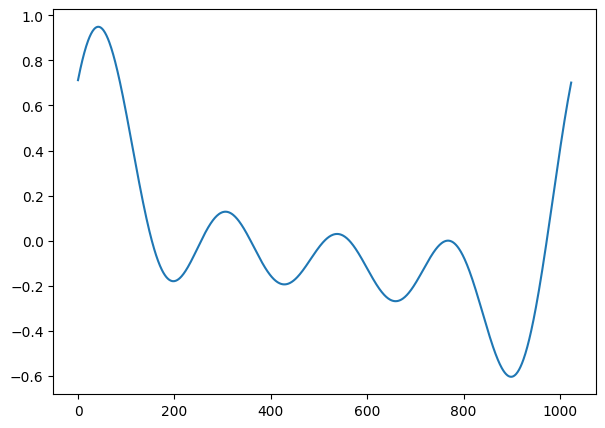

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(u_out[0])

In [25]:
num_parameters(model)

165313

In [ ]:
# model = FNO1D(
#     data_dim=1, lift_dim=64, depth=4, frequency_modes=8, key=jax.random.PRNGKey(0)
# )


TypeError: FNO1D.__init__() got an unexpected keyword argument 'data_dim'

In [13]:
out = fno(sol[0])

2025-07-29 01:36:37.117089: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), window={size=1}, dim_labels=bf0_oi0->bf0, custom_call_target="__cudnn$convForward", metadata={op_name="jit(conv_general_dilated)/jit(main)/conv_general_dilated" source_file="/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/equinox/nn/_conv.py" source_line=238}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-07-29 01:36:40.975288: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.858323399s
Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), 

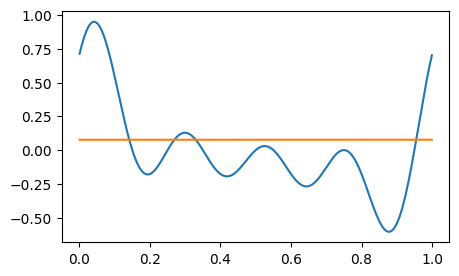

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(xc, sol[0][0])
ax.plot(xc, out[0])

In [15]:
sol[1:501].shape

(500, 1, 1024)

In [14]:
import optax


@eqx.filter_value_and_grad
def loss_fn(model, u0, u1):
    u1_pred = eqx.filter_vmap(model, in_axes=(0, None, None))(
        u0, 6.0 / 1000, 1.0 / 1024
    )
    return jnp.mean((u1_pred - u1) ** 2)


optim = optax.adabelief(learning_rate=1e-3)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


@eqx.filter_jit
def make_step(model, u0, u1, opt_state):
    loss, grads = loss_fn(model, u0, u1)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [15]:
sol = jnp.asarray(data_array[0])
sol.shape

(1001, 1, 1024)

In [16]:
max_epochs = 1000
loss_history = []
for i in range(max_epochs):
    model, opt_state, loss = make_step(model, sol[0:300], sol[1:301], opt_state)
    loss_history.append(loss)
    print(f"Epoch = {i}: Loss = {loss.item()}")

Epoch = 0: Loss = 0.0005161681187226657
Epoch = 1: Loss = 0.0005158406756265919
Epoch = 2: Loss = 0.0005154977784066621
Epoch = 3: Loss = 0.000515122003697004
Epoch = 4: Loss = 0.0005146923125998957
Epoch = 5: Loss = 0.0005141822013877835
Epoch = 6: Loss = 0.0005135569455099677
Epoch = 7: Loss = 0.0005127694222764438
Epoch = 8: Loss = 0.0005117537665198371
Epoch = 9: Loss = 0.0005104156859939352
Epoch = 10: Loss = 0.000508617560278349
Epoch = 11: Loss = 0.000506155460126932
Epoch = 12: Loss = 0.0005027239956069132
Epoch = 13: Loss = 0.0004978638331798654
Epoch = 14: Loss = 0.0004908871757632568
Epoch = 15: Loss = 0.000480781879565681
Epoch = 16: Loss = 0.0004661123852537025
Epoch = 17: Loss = 0.000444979654092726
Epoch = 18: Loss = 0.0004152048530624698
Epoch = 19: Loss = 0.00037514740788685184
Epoch = 20: Loss = 0.000326232207526968
Epoch = 21: Loss = 0.000280084890444387
Epoch = 22: Loss = 0.0002717303952599079
Epoch = 23: Loss = 0.0002992213077430029
Epoch = 24: Loss = 0.00028470263

Text(0, 0.5, 'Train loss')

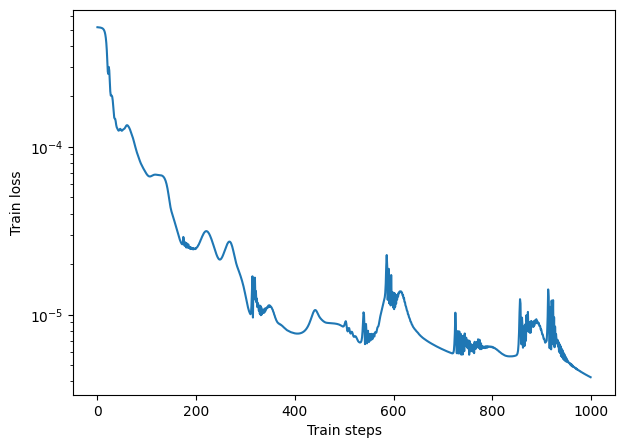

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(loss_history)
ax.set_yscale("log", base=10)
ax.set_xlabel("Train steps")
ax.set_ylabel("Train loss")

In [27]:
float(data_array.t[1] - data_array.t[0])

0.006

Text(0, 0.5, '$u_{pred}-u_{data}$')

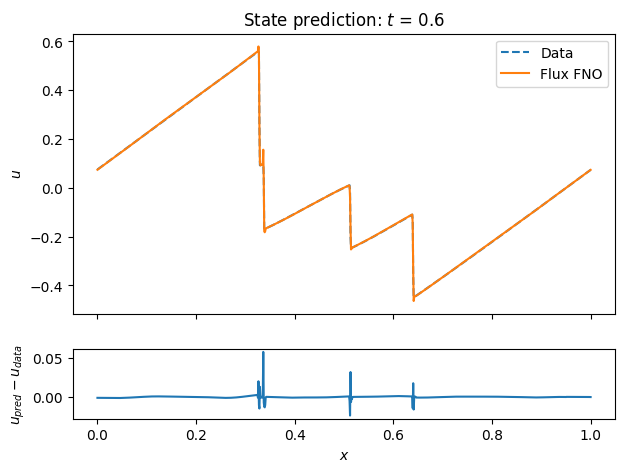

In [34]:
time_idx = 100
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, height_ratios=(4, 1))
u_data = sol[time_idx + 1][0]
u_pred = model(sol[time_idx], 6.0 / 1000, 1.0 / 1024)[0]
axes[0].plot(data_array.x, u_data, "--", label="Data")
axes[0].plot(data_array.x, u_pred, label="Flux FNO")
axes[0].legend()

axes[0].set_ylabel("$u$")
axes[0].set_title(
    f"State prediction: $t$ = {time_idx * float(data_array.t[1] - data_array.t[0])}"
)
axes[1].plot(data_array.x, u_pred - u_data)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$u_{pred}-u_{data}$")

Text(0.5, 1.0, 'Flux prediction: $t$ = 0.6')

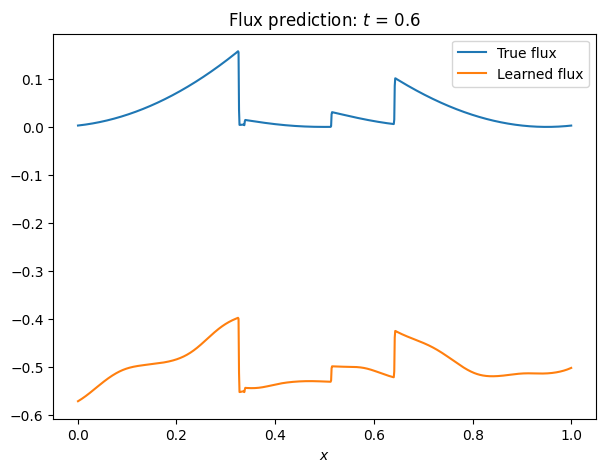

In [39]:
time_idx = 100
f_pred = model.physical_flux(sol[time_idx])
f_true = 0.5 * sol[time_idx] ** 2
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(data_array.x, f_true[0], label="True flux")
ax.plot(data_array.x, f_pred[0], label="Learned flux")
ax.legend()
ax.set_xlabel("$x$")
ax.set_title(
    f"Flux prediction: $t$ = {time_idx * float(data_array.t[1] - data_array.t[0])}"
)